In [ ]:
import json
import os
import numpy as np
import pandas as pd
from Bio.PDB.MMCIFParser import MMCIFParser
from Bio.PDB.Superimposer import Superimposer

HYDROPHOBICITY = {'A': 1.8, 'R': -4.5, 'N': -3.5, 'D': -3.5, 'C': 2.5, 'Q': -3.5, 'E': -3.5, 'G': -0.4, 'H': -3.2, 'I': 4.5, 'L': 3.8, 'K': -3.9, 'M': 1.9, 'F': 2.8, 'P': -1.6, 'S': -0.8, 'T': -0.7, 'W': -0.9, 'Y': -1.3, 'V': 4.2}
CHARGE = {'R': 1, 'K': 1, 'H': 0.1, 'D': -1, 'E': -1, 'A': 0, 'N': 0, 'C': 0, 'Q': 0, 'G': 0, 'I': 0, 'L': 0, 'M': 0, 'F': 0, 'P': 0, 'S': 0, 'T': 0, 'W': 0, 'Y': 0, 'V': 0}

def get_boltz_data(base_path, job_name):
    # Each job has its own boltz_results folder at the top level
    results_folder = f"boltz_results_{job_name}"
    pred_path = os.path.join(base_path, results_folder, "predictions", job_name)
    
    cif_file = os.path.join(pred_path, f"{job_name}_model_0.cif")
    json_file = os.path.join(pred_path, f"affinity_{job_name}.json")
    
    if not os.path.exists(cif_file):
        raise FileNotFoundError(f"Missing CIF: {cif_file}")
    if not os.path.exists(json_file):
        raise FileNotFoundError(f"Missing JSON: {json_file}")
        
    return cif_file, json_file

def extract_biophysical_vector(wt_info, mut_info, chain_id='A'):
    parser = MMCIFParser(QUIET=True)
    wt_struct = parser.get_structure("WT", wt_info['cif'])[0]
    mut_struct = parser.get_structure("MUT", mut_info['cif'])[0]

    # Global backbone alignment
    wt_ca = [a for a in wt_struct.get_atoms() if a.name == 'CA']
    mut_ca = [a for a in mut_struct.get_atoms() if a.name == 'CA']
    super_imposer = Superimposer()
    super_imposer.set_atoms(wt_ca, mut_ca)
    super_imposer.apply(mut_struct.get_atoms())

    # Site 1 Pocket Definition (D137, S315) [cite: 102, 186, 741, 949]
    anchors = [wt_struct[chain_id][res]['CA'] for res in [137, 315] if res in wt_struct[chain_id]]
    # Select residues within 10A of the entry channel anchors [cite: 170, 753]
    pocket_res = [r.id[1] for r in wt_struct[chain_id] if 'CA' in r and any(np.linalg.norm(r['CA'].coord - a.coord) <= 10.0 for a in anchors)]

    wt_p_ca = [wt_struct[chain_id][r]['CA'] for r in pocket_res if r in mut_struct[chain_id]]
    mut_p_ca = [mut_struct[chain_id][r]['CA'] for r in pocket_res if r in mut_struct[chain_id]]

    dist = [np.linalg.norm(w.coord - m.coord) for w, m in zip(wt_p_ca, mut_p_ca)]
    
    with open(wt_info['aff'], 'r') as f: wt_aff = json.load(f)['affinity_pred_value']
    with open(mut_info['aff'], 'r') as f: mut_aff = json.load(f)['affinity_pred_value']

    return {
        "variant": mut_info['name'],
        "rmsd_site1_pocket": np.sqrt(np.mean(np.square(dist))),
        "mean_ca_displacement": np.mean(dist),
        "boltz_affinity_shift": mut_aff - wt_aff,
        "delta_hydrophobicity": HYDROPHOBICITY[mut_info['mut_aa']] - HYDROPHOBICITY[wt_info['wt_aa']],
        "delta_charge": CHARGE[mut_info['mut_aa']] - CHARGE[wt_info['wt_aa']]
    }

In [2]:
# --- Execution ---
base = os.path.expanduser('~/Notebooks/Boltz2/katG')
wt_job = "katG_INH_monomer"
wt_cif, wt_aff = get_boltz_data(base, wt_job)

results = []

for folder in os.listdir(base):
    if folder.startswith(f"boltz_results_{wt_job}_"):
        job = folder.replace("boltz_results_", "")
        name = job.split('_')[-1]
        wt_aa, mut_aa = name[0], name[-1]

        try:
            m_cif, m_aff = get_boltz_data(base, job)
            wt_input = {"cif": wt_cif, "aff": wt_aff, "wt_aa": wt_aa}
            mut_input = {"cif": m_cif, "aff": m_aff, "name": name, "mut_aa": mut_aa}
            results.append(extract_biophysical_vector(wt_input, mut_input))
        except Exception as e:
            print(f"Skipping {name}: {e}")

df = pd.DataFrame(results)
print(df)

  variant  rmsd_site1_pocket  mean_ca_displacement  boltz_affinity_shift  \
0   S315W           1.242517              1.219086             -0.398281   
1   D137R           0.243448              0.221608              0.064902   
2   T275P           0.623885              0.608592              0.032597   
3   S315D           0.554817              0.509884              0.325110   
4   D137W           1.188466              1.168783             -0.212508   
5   S315R           0.806056              0.538996              0.115064   
6   D137A           0.927623              0.909473              0.095065   
7   S315A           0.384971              0.351864             -0.018566   

   delta_hydrophobicity  delta_charge  
0                  -0.1             0  
1                  -1.0             2  
2                  -0.9             0  
3                  -2.7            -1  
4                   2.6             1  
5                  -3.7             1  
6                   5.3            

Text(786.4027777777777, 0.5, '')

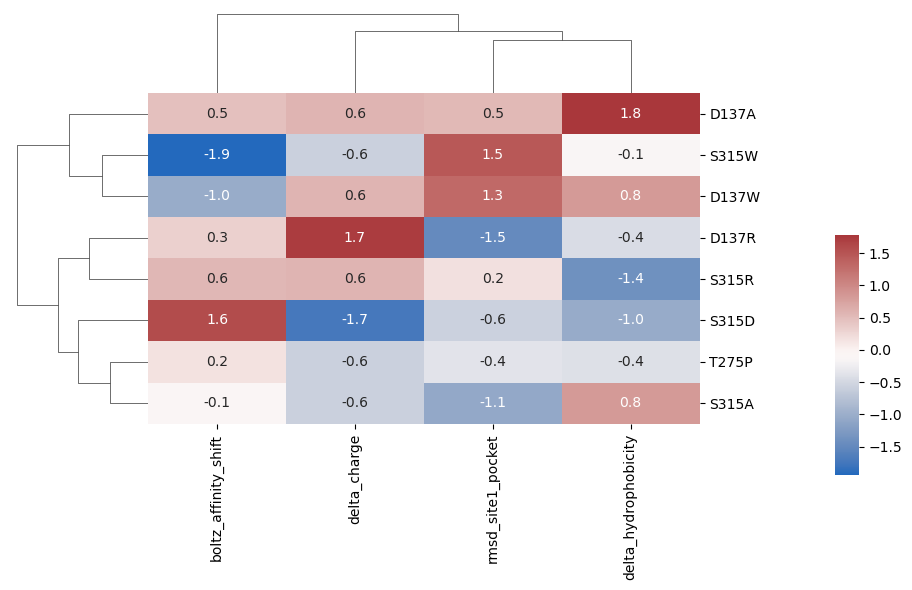

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch

features = ['rmsd_site1_pocket', 'boltz_affinity_shift', 'delta_hydrophobicity', 'delta_charge']
X = df[features]

X_scaled = StandardScaler().fit_transform(X)
df_scaled = pd.DataFrame(X_scaled, columns=features, index=df['variant'])

g = sns.clustermap(
    df_scaled,
    method='ward',
    metric='euclidean',
    cmap='vlag',
    figsize=(8, 6),
    dendrogram_ratio=(0.2, 0.2),
    cbar_pos=(1.05, 0.2, 0.03, 0.4),
    annot=True,
    fmt=".1f"
)

g.ax_heatmap.set_ylabel('')